# Fluorescence microscopy particle detection

`data/fluorescence_microscopy_sample.tiff` を読み込み、輝度補正・しきい値・面積などのパラメータを調整しながら粒を検出します。

実行前に、このリポジトリの `.venv` から Jupyter Notebook を起動してください。

## 1. Imports and settings

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt

from scipy import ndimage as ndi
from skimage import exposure, feature, filters, measure, morphology, segmentation, util

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

DATA_DIR = Path('data')
IMAGE_PATH = DATA_DIR / 'fluorescence_microscopy_sample.tiff'
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['image.cmap'] = 'gray'

## 2. Load TIFF

In [8]:
def load_tiff(path):
    arr = tifffile.imread(path)
    arr = np.asarray(arr)
    return arr


raw = load_tiff(IMAGE_PATH)
print(f'path: {IMAGE_PATH}')
print(f'shape: {raw.shape}')
print(f'dtype: {raw.dtype}')
print(f'min/max/mean: {raw.min()} / {raw.max()} / {raw.mean():.3f}')

path: data\fluorescence_microscopy_sample.tiff
shape: (1086, 1448, 3)
dtype: uint8
min/max/mean: 0 / 255 / 14.557


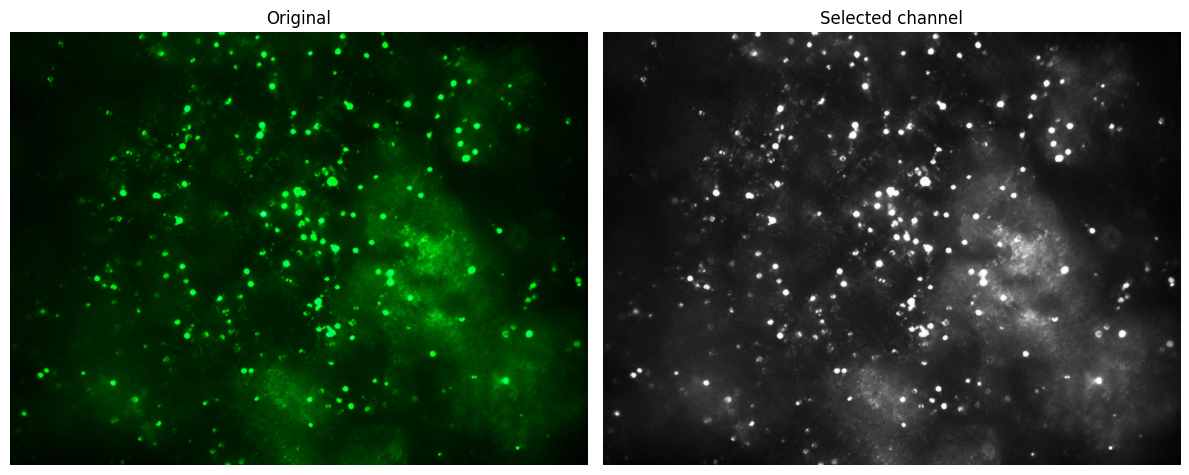

In [9]:
def select_channel(image, channel='green'):
    image = np.asarray(image)

    if image.ndim == 2:
        return image

    if image.ndim == 3 and image.shape[-1] in (3, 4):
        channels = {
            'red': 0,
            'green': 1,
            'blue': 2,
            'alpha': 3,
        }
        if channel == 'max':
            return image[..., :3].max(axis=-1)
        if channel == 'mean':
            return image[..., :3].mean(axis=-1)
        return image[..., channels.get(channel, 1)]

    if image.ndim == 3:
        if channel == 'max':
            return image.max(axis=0)
        if channel == 'mean':
            return image.mean(axis=0)
        return image[0]

    raise ValueError(f'Unsupported image shape: {image.shape}')


preview = select_channel(raw, channel='green')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if raw.ndim == 3 and raw.shape[-1] in (3, 4):
    axes[0].imshow(raw[..., :3])
else:
    axes[0].imshow(preview, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(preview, cmap='gray')
axes[1].set_title('Selected channel')
axes[1].axis('off')
plt.tight_layout()

## 3. Detection functions

主な調整パラメータ:

- `channel`: 検出に使うチャンネル
- `p_low`, `p_high`: コントラスト補正に使うパーセンタイル
- `background_sigma`: 背景ムラを引く強さ。0で無効
- `smooth_sigma`: ノイズを抑えるガウシアン平滑化
- `threshold_method`: `otsu`, `local`, `manual`
- `manual_threshold`: 手動しきい値
- `min_area`, `max_area`: 検出する粒の面積範囲
- `min_distance`: watershedで粒を分離する距離

In [10]:
def normalize_float(image, p_low=1.0, p_high=99.8):
    image = util.img_as_float(image)
    low, high = np.percentile(image, [p_low, p_high])
    if high <= low:
        return np.zeros_like(image, dtype=float)
    return exposure.rescale_intensity(image, in_range=(low, high), out_range=(0.0, 1.0))


def preprocess_image(image, channel='green', p_low=1.0, p_high=99.8, background_sigma=20.0, smooth_sigma=1.2):
    selected = select_channel(image, channel=channel)
    normalized = normalize_float(selected, p_low=p_low, p_high=p_high)

    if background_sigma and background_sigma > 0:
        background = filters.gaussian(normalized, sigma=background_sigma, preserve_range=True)
        corrected = normalized - background
        corrected = exposure.rescale_intensity(corrected, out_range=(0.0, 1.0))
    else:
        corrected = normalized

    if smooth_sigma and smooth_sigma > 0:
        smoothed = filters.gaussian(corrected, sigma=smooth_sigma, preserve_range=True)
    else:
        smoothed = corrected

    return selected, normalized, corrected, smoothed


def threshold_image(image, method='otsu', manual_threshold=0.25, local_block_size=51, local_offset=0.0):
    if method == 'manual':
        threshold = manual_threshold
        mask = image > threshold
    elif method == 'local':
        block_size = int(local_block_size)
        if block_size % 2 == 0:
            block_size += 1
        threshold = filters.threshold_local(image, block_size=block_size, offset=local_offset)
        mask = image > threshold
    else:
        threshold = filters.threshold_otsu(image)
        mask = image > threshold
    return mask, threshold


def segment_particles(mask, min_area=20, max_area=2000, clear_border=False, split_touching=True, min_distance=5):
    cleaned = morphology.remove_small_objects(mask.astype(bool), min_size=int(min_area))
    cleaned = morphology.remove_small_holes(cleaned, area_threshold=int(min_area))
    if clear_border:
        cleaned = segmentation.clear_border(cleaned)

    if split_touching:
        distance = ndi.distance_transform_edt(cleaned)
        coords = feature.peak_local_max(distance, min_distance=int(min_distance), labels=cleaned)
        markers = np.zeros(distance.shape, dtype=int)
        if len(coords) > 0:
            markers[tuple(coords.T)] = np.arange(1, len(coords) + 1)
            markers = measure.label(markers > 0)
            labels = segmentation.watershed(-distance, markers, mask=cleaned)
        else:
            labels = measure.label(cleaned)
    else:
        labels = measure.label(cleaned)

    if max_area and max_area > 0:
        props = measure.regionprops(labels)
        keep = np.zeros(labels.max() + 1, dtype=bool)
        for prop in props:
            keep[prop.label] = min_area <= prop.area <= max_area
        labels = keep[labels] * labels
        labels = measure.label(labels > 0)

    return cleaned, labels


def measure_particles(labels, intensity_image):
    if labels.max() == 0:
        return pd.DataFrame(columns=['label', 'area', 'centroid_y', 'centroid_x', 'mean_intensity', 'max_intensity'])

    table = measure.regionprops_table(
        labels,
        intensity_image=intensity_image,
        properties=('label', 'area', 'centroid', 'mean_intensity', 'max_intensity', 'equivalent_diameter_area')
    )
    df = pd.DataFrame(table)
    df = df.rename(columns={
        'centroid-0': 'centroid_y',
        'centroid-1': 'centroid_x',
        'equivalent_diameter_area': 'equivalent_diameter',
    })
    return df

## 4. Interactive parameter tuning

In [11]:
def run_detection(
    channel='green',
    p_low=1.0,
    p_high=99.8,
    background_sigma=20.0,
    smooth_sigma=1.2,
    threshold_method='otsu',
    manual_threshold=0.25,
    local_block_size=51,
    local_offset=0.0,
    min_area=20,
    max_area=2000,
    clear_border=False,
    split_touching=True,
    min_distance=5,
    show_labels=True,
):
    selected, normalized, corrected, smoothed = preprocess_image(
        raw,
        channel=channel,
        p_low=p_low,
        p_high=p_high,
        background_sigma=background_sigma,
        smooth_sigma=smooth_sigma,
    )
    mask, threshold = threshold_image(
        smoothed,
        method=threshold_method,
        manual_threshold=manual_threshold,
        local_block_size=local_block_size,
        local_offset=local_offset,
    )
    cleaned, labels = segment_particles(
        mask,
        min_area=min_area,
        max_area=max_area,
        clear_border=clear_border,
        split_touching=split_touching,
        min_distance=min_distance,
    )
    df = measure_particles(labels, corrected)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    axes[0].imshow(selected, cmap='gray')
    axes[0].set_title('Selected channel')
    axes[1].imshow(corrected, cmap='gray')
    axes[1].set_title('Background corrected')
    axes[2].imshow(smoothed, cmap='gray')
    if np.ndim(threshold) == 0:
        axes[2].set_title(f'Smoothed, threshold={threshold:.3f}')
    else:
        axes[2].set_title('Smoothed, local threshold')

    axes[3].imshow(mask, cmap='gray')
    axes[3].set_title('Initial mask')
    axes[4].imshow(cleaned, cmap='gray')
    axes[4].set_title('Cleaned mask')

    axes[5].imshow(corrected, cmap='gray')
    if labels.max() > 0:
        axes[5].contour(labels > 0, colors='yellow', linewidths=0.6)
        if show_labels:
            for _, row in df.iterrows():
                axes[5].text(row['centroid_x'], row['centroid_y'], int(row['label']), color='cyan', fontsize=7)
    axes[5].set_title(f'Detected particles: {len(df)}')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    display(df.head(20))
    return df, labels, corrected


if HAS_WIDGETS:
    controls = widgets.interactive(
        run_detection,
        channel=widgets.Dropdown(options=['green', 'red', 'blue', 'max', 'mean'], value='green', description='channel'),
        p_low=widgets.FloatSlider(value=1.0, min=0.0, max=20.0, step=0.5, description='p_low'),
        p_high=widgets.FloatSlider(value=99.8, min=80.0, max=100.0, step=0.1, description='p_high'),
        background_sigma=widgets.FloatSlider(value=20.0, min=0.0, max=80.0, step=1.0, description='bg_sigma'),
        smooth_sigma=widgets.FloatSlider(value=1.2, min=0.0, max=5.0, step=0.1, description='smooth'),
        threshold_method=widgets.Dropdown(options=['otsu', 'local', 'manual'], value='otsu', description='threshold'),
        manual_threshold=widgets.FloatSlider(value=0.25, min=0.0, max=1.0, step=0.01, description='manual'),
        local_block_size=widgets.IntSlider(value=51, min=11, max=301, step=2, description='block'),
        local_offset=widgets.FloatSlider(value=0.0, min=-0.2, max=0.2, step=0.005, description='offset'),
        min_area=widgets.IntSlider(value=20, min=1, max=1000, step=1, description='min_area'),
        max_area=widgets.IntSlider(value=2000, min=10, max=20000, step=10, description='max_area'),
        clear_border=widgets.Checkbox(value=False, description='clear_border'),
        split_touching=widgets.Checkbox(value=True, description='split'),
        min_distance=widgets.IntSlider(value=5, min=1, max=50, step=1, description='distance'),
        show_labels=widgets.Checkbox(value=True, description='labels'),
    )
    display(controls)
else:
    latest_df, latest_labels, latest_image = run_detection()

interactive(children=(Dropdown(description='channel', options=('green', 'red', 'blue', 'max', 'mean'), value='…

## 5. Run once with fixed parameters and save results

インタラクティブ調整で良さそうな値が見つかったら、下の `params` を同じ値にして実行してください。結果CSVとラベル画像を `outputs/` に保存します。

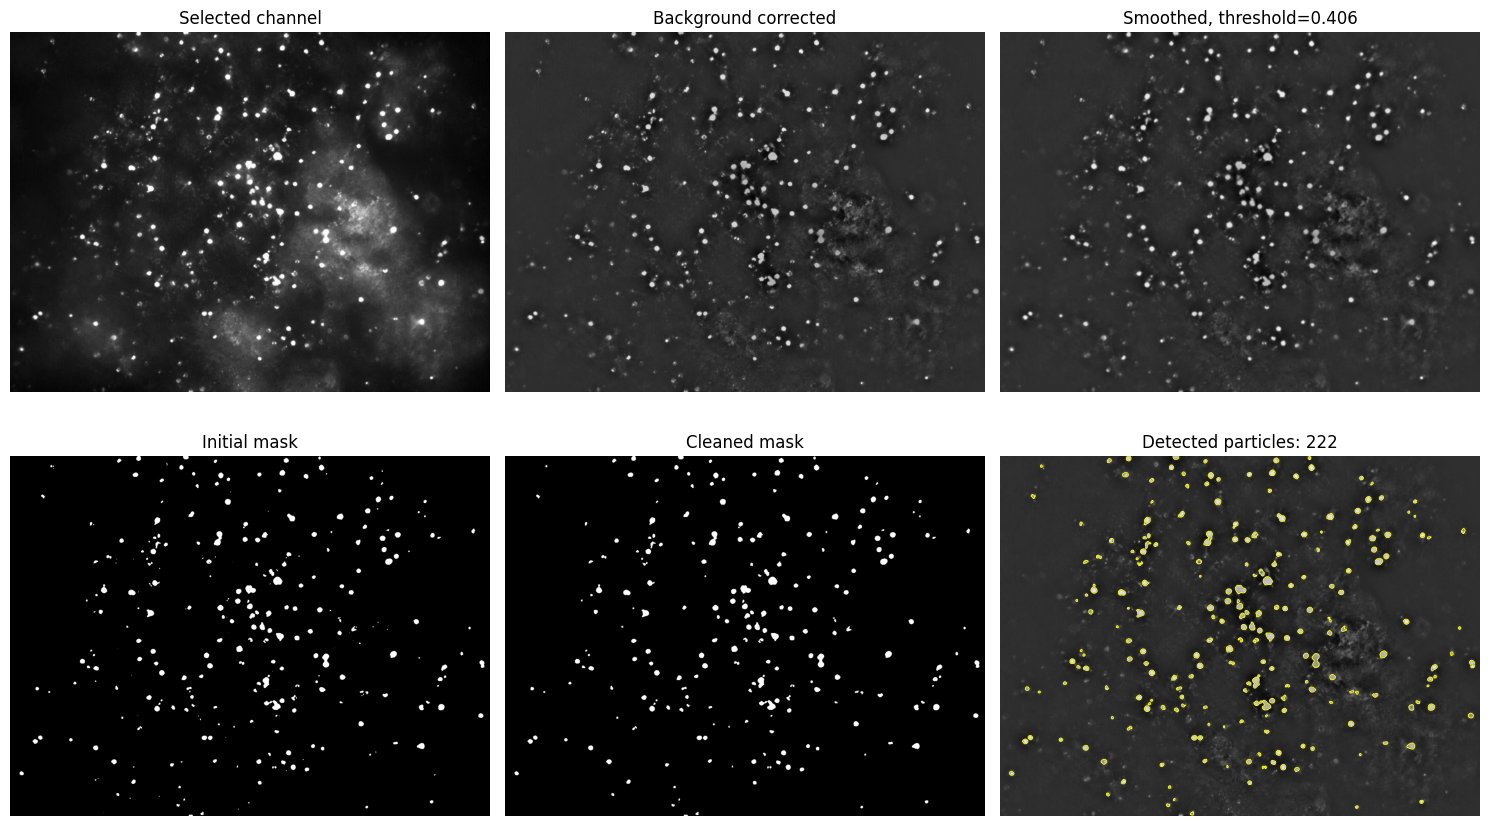

,label,area,centroid_y,centroid_x,mean_intensity,max_intensity,equivalent_diameter
0,1,171.0,6.777778,387.619883,0.739182,0.862956,14.755472
1,2,150.0,4.133333,530.086667,0.692938,0.769109,13.819766
2,3,55.0,5.709091,933.381818,0.594076,0.926922,8.368284
3,4,169.0,12.958580,832.828402,0.705936,0.890986,14.668929
4,5,106.0,13.500000,328.801887,0.581272,0.886800,11.617375
5,6,77.0,15.337662,619.285714,0.692978,0.897068,9.901487
6,7,215.0,34.655814,939.293023,0.778787,0.911728,16.545286
7,8,33.0,30.181818,124.303030,0.542580,0.819735,6.482045
8,9,138.0,33.847826,516.601449,0.734515,0.874858,13.255454
9,10,227.0,50.563877,821.079295,0.761730,0.903320,17.000746


saved: outputs\particle_measurements.csv
saved: outputs\particle_labels.tiff


In [12]:
params = dict(
    channel='green',
    p_low=1.0,
    p_high=99.8,
    background_sigma=20.0,
    smooth_sigma=1.2,
    threshold_method='otsu',
    manual_threshold=0.25,
    local_block_size=51,
    local_offset=0.0,
    min_area=20,
    max_area=2000,
    clear_border=False,
    split_touching=True,
    min_distance=5,
    show_labels=False,
)

latest_df, latest_labels, latest_image = run_detection(**params)

csv_path = OUTPUT_DIR / 'particle_measurements.csv'
labels_path = OUTPUT_DIR / 'particle_labels.tiff'

latest_df.to_csv(csv_path, index=False)
tifffile.imwrite(labels_path, latest_labels.astype(np.uint16))

print(f'saved: {csv_path}')
print(f'saved: {labels_path}')